# Mutual Fund Analytics - Performance Analytics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import sqlite3
import os

os.makedirs('../reports/charts', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# Connect to database
conn = sqlite3.connect('../bluestock_mf.db')

# Load dim_fund
df_fund = pd.read_sql('SELECT amfi_code, scheme_name, expense_ratio_pct FROM dim_fund', conn)
fund_dict = dict(zip(df_fund['amfi_code'], df_fund['scheme_name']))

# Load NAV
df_nav = pd.read_sql('SELECT amfi_code, date, nav FROM fact_nav ORDER BY date', conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])

# Pivot NAV
nav_pivot = df_nav.pivot(index='date', columns='amfi_code', values='nav')

# Load Benchmarks
df_bench = pd.read_csv('../data/processed/10_benchmark_indices.csv')
df_bench['date'] = pd.to_datetime(df_bench['date'])
bench_pivot = df_bench.pivot(index='date', columns='index_name', values='close_value')

# Keep matching dates
common_dates = nav_pivot.index.intersection(bench_pivot.index)
nav_pivot = nav_pivot.loc[common_dates]
bench_pivot = bench_pivot.loc[common_dates]

print("Data loaded successfully.")

Data loaded successfully.


## 1. Daily Returns
Compute daily returns for all schemes and benchmark indices.

In [2]:
fund_returns = nav_pivot.pct_change().dropna()
bench_returns = bench_pivot.pct_change().dropna()

display(fund_returns.head())

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680
2022-01-10,-0.008639,0.006791,0.006277,0.011548,0.001251,0.000690,-0.001202,-0.000722,-0.011593,0.006360,...,-0.002583,0.000853,0.003057,-0.019536,0.024234,-0.011127,0.009372,0.001601,0.003650,0.001356


## 2. CAGR (1yr, 3yr, 5yr)
Calculate Compound Annual Growth Rate.

In [3]:
def calc_cagr(series, years):
    # Get NAV start and end for the required window
    # Assuming 252 trading days per year
    days = years * 252
    if len(series) <= days:
        return np.nan
    nav_end = series.iloc[-1]
    nav_start = series.iloc[-days]
    return ((nav_end / nav_start) ** (1/years)) - 1

cagr_data = []
for col in nav_pivot.columns:
    cagr_data.append({
        'amfi_code': col,
        'CAGR_1Yr': calc_cagr(nav_pivot[col].dropna(), 1),
        'CAGR_3Yr': calc_cagr(nav_pivot[col].dropna(), 3),
        'CAGR_5Yr': calc_cagr(nav_pivot[col].dropna(), 5) # Note: dataset might be <5 yrs, will return NaN
    })
df_cagr = pd.DataFrame(cagr_data)
display(df_cagr.head())

,amfi_code,CAGR_1Yr,CAGR_3Yr,CAGR_5Yr
0,100016,-0.033055,-0.000316,NaN
1,100025,0.025018,0.046143,NaN
2,100033,0.477346,0.336292,NaN
3,101206,0.450939,0.325286,NaN
4,101207,-0.242421,-0.026965,NaN


## 3. Sharpe & Sortino Ratios
Compute Sharpe and Sortino ratios. Risk-free rate (Rf) = 6.5%

In [4]:
rf_daily = 0.065 / 252

ratios_data = []
for col in fund_returns.columns:
    rets = fund_returns[col]
    excess_rets = rets - rf_daily
    
    # Sharpe
    ann_ret = rets.mean() * 252
    ann_vol = rets.std() * np.sqrt(252)
    sharpe = (ann_ret - 0.065) / ann_vol if ann_vol > 0 else np.nan
    
    # Sortino
    downside = excess_rets[excess_rets < 0]
    down_vol = downside.std() * np.sqrt(252) if len(downside) > 0 else np.nan
    sortino = (ann_ret - 0.065) / down_vol if down_vol > 0 else np.nan
    
    ratios_data.append({
        'amfi_code': col,
        'Sharpe_Ratio': sharpe,
        'Sortino_Ratio': sortino
    })

df_ratios = pd.DataFrame(ratios_data)
display(df_ratios.sort_values('Sharpe_Ratio', ascending=False).head())

,amfi_code,Sharpe_Ratio,Sortino_Ratio
34,148567,1.448291,2.368342
30,120843,1.306744,2.352942
36,148569,1.234930,2.135083
19,119551,1.208267,2.103952
25,120505,1.180101,2.010035


## 4. Alpha & Beta
OLS regression of fund returns vs Nifty 100.

In [5]:
nifty100_rets = bench_returns['NIFTY100']

alpha_beta_data = []
for col in fund_returns.columns:
    rets = fund_returns[col]
    # Align dates
    df_reg = pd.concat([rets, nifty100_rets], axis=1).dropna()
    df_reg.columns = ['fund', 'bench']
    
    if len(df_reg) > 30:
        slope, intercept, r_value, p_value, std_err = stats.linregress(df_reg['bench'], df_reg['fund'])
        alpha_ann = intercept * 252
        beta = slope
    else:
        alpha_ann = np.nan
        beta = np.nan
        
    alpha_beta_data.append({
        'amfi_code': col,
        'Alpha': alpha_ann,
        'Beta': beta
    })

df_ab = pd.DataFrame(alpha_beta_data)
df_ab.to_csv('../reports/alpha_beta.csv', index=False)
display(df_ab.head())

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


## 5. Maximum Drawdown
Calculate the maximum peak-to-trough drop.

In [6]:
dd_data = []
for col in nav_pivot.columns:
    series = nav_pivot[col].dropna()
    roll_max = series.cummax()
    drawdown = (series / roll_max) - 1
    max_dd = drawdown.min()
    worst_date = drawdown.idxmin()
    
    dd_data.append({
        'amfi_code': col,
        'Max_Drawdown': max_dd,
        'Worst_Date': worst_date
    })

df_dd = pd.DataFrame(dd_data)
display(df_dd.head())

,amfi_code,Max_Drawdown,Worst_Date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


## 6. Composite Fund Scorecard
Rank calculation (0-100) based on multiple metrics.

In [7]:
df_score = df_fund.merge(df_cagr, on='amfi_code')
df_score = df_score.merge(df_ratios, on='amfi_code')
df_score = df_score.merge(df_ab, on='amfi_code')
df_score = df_score.merge(df_dd, on='amfi_code')

# Handle NaNs for ranking
for col in ['CAGR_3Yr', 'Sharpe_Ratio', 'Alpha']:
    df_score[col] = df_score[col].fillna(df_score[col].median())

# Rankings (percentiles 0 to 1)
rank_3yr = df_score['CAGR_3Yr'].rank(pct=True)
rank_sharpe = df_score['Sharpe_Ratio'].rank(pct=True)
rank_alpha = df_score['Alpha'].rank(pct=True)
# Inverse rankings (lower is better)
rank_er = df_score['expense_ratio_pct'].rank(pct=True, ascending=False)
rank_dd = df_score['Max_Drawdown'].rank(pct=True) # Max_Drawdown is negative, so higher rank is better, wait, closer to 0 is better, so min() is worst. 
# Rank ascending=False means the highest (closest to 0) gets top score.
rank_dd = df_score['Max_Drawdown'].rank(pct=True, ascending=False)

# Composite Score
df_score['Scorecard'] = (0.30 * rank_3yr + 
                         0.25 * rank_sharpe + 
                         0.20 * rank_alpha + 
                         0.15 * rank_er + 
                         0.10 * rank_dd) * 100

df_score = df_score.sort_values('Scorecard', ascending=False)
df_score.to_csv('../reports/fund_scorecard.csv', index=False)
print("Scorecard saved to reports/fund_scorecard.csv")
display(df_score[['scheme_name', 'Scorecard', 'CAGR_3Yr', 'Sharpe_Ratio', 'Alpha', 'Max_Drawdown']].head(10))

Scorecard saved to reports/fund_scorecard.csv


,scheme_name,Scorecard,CAGR_3Yr,Sharpe_Ratio,Alpha,Max_Drawdown
25,ICICI Pru Midcap Fund - Regular - Growth,84.5000,0.302065,1.180101,0.292636,-0.181885
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,82.0000,0.336292,1.093699,0.271954,-0.162172
16,Axis Midcap Fund - Regular - Growth,80.7500,0.360660,0.998231,0.260767,-0.209609
21,SBI Small Cap Fund - Regular Plan - Growth,78.8750,0.278144,0.945308,0.303370,-0.287060
34,Mirae Asset Large Cap Fund - Regular - Growth,78.5000,0.312786,1.448291,0.269838,-0.112657
30,Kotak Flexicap Fund - Regular - Growth,76.0000,0.256619,1.306744,0.273305,-0.129740
39,DSP Small Cap Fund - Regular - Growth,74.1875,0.250297,0.949796,0.300579,-0.311719
24,ICICI Pru Bluechip Fund - Direct - Growth,73.5000,0.283698,1.026524,0.211948,-0.125883
19,SBI Bluechip Fund - Regular Plan - Growth,71.5625,0.277274,1.208267,0.232010,-0.150124
36,Mirae Asset Tax Saver Fund - Regular - Growth,70.1875,0.233171,1.234930,0.282704,-0.163967


## 7. Benchmark Comparison & Tracking Error
Plot top 5 funds vs Nifty 50 and Nifty 100.

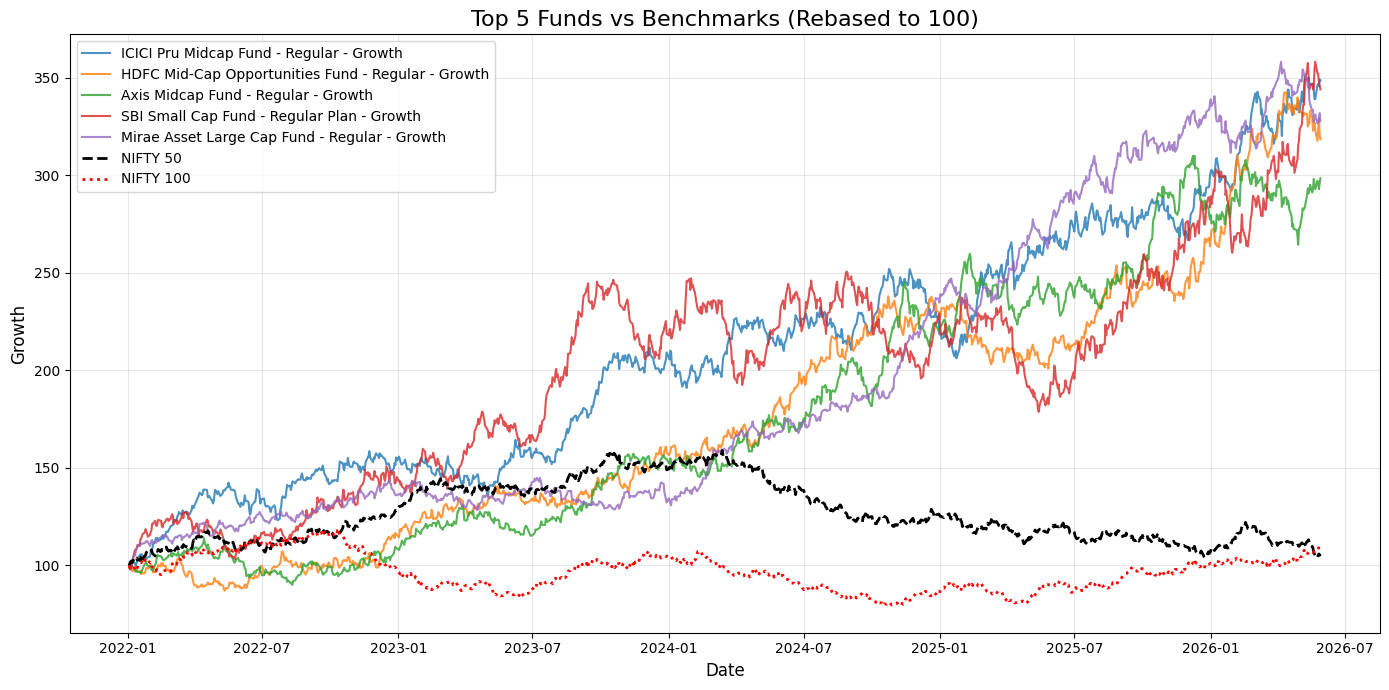

Annualized Tracking Error vs NIFTY 50:
ICICI Pru Midcap Fund - Regular - Growth: 23.31%
HDFC Mid-Cap Opportunities Fund - Regular - Growth: 22.98%
Axis Midcap Fund - Regular - Growth: 23.71%
SBI Small Cap Fund - Regular Plan - Growth: 27.80%
Mirae Asset Large Cap Fund - Regular - Growth: 19.40%


In [8]:
top_5_codes = df_score['amfi_code'].head(5).tolist()

plt.figure(figsize=(14, 7))

# Rebase everything to 100 at the start of the common date window
start_date = nav_pivot.index.min()
nav_rebased = (nav_pivot[top_5_codes] / nav_pivot[top_5_codes].iloc[0]) * 100
bench_rebased = (bench_pivot[['NIFTY50', 'NIFTY100']] / bench_pivot[['NIFTY50', 'NIFTY100']].iloc[0]) * 100

for col in top_5_codes:
    plt.plot(nav_rebased.index, nav_rebased[col], label=fund_dict[col], alpha=0.8)

plt.plot(bench_rebased.index, bench_rebased['NIFTY50'], label='NIFTY 50', color='black', linewidth=2, linestyle='--')
plt.plot(bench_rebased.index, bench_rebased['NIFTY100'], label='NIFTY 100', color='red', linewidth=2, linestyle=':')

plt.title('Top 5 Funds vs Benchmarks (Rebased to 100)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Growth', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/charts/benchmark_comparison_chart.png')
plt.show()

# Calculate Tracking Error vs Nifty 50
print("Annualized Tracking Error vs NIFTY 50:")
for col in top_5_codes:
    te_daily = (fund_returns[col] - bench_returns['NIFTY50']).std()
    te_ann = te_daily * np.sqrt(252)
    print(f"{fund_dict[col]}: {te_ann:.2%}")